<a href="https://colab.research.google.com/github/cuenta003/BCJS/blob/main/Copia_de_classroom7_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Clase 7: Manipulación Avanzada de DataFrames**
**Continuación: Análisis Profundo del Dataset GDP**

**Objetivos de la clase:**
- Aplicar técnicas avanzadas de manipulación de DataFrames
- Responder preguntas específicas usando pandas
- Practicar limpieza y transformación de datos
- Introducir visualizaciones básicas para análisis exploratorio

**Duración:** 1 hora 30 minutos

## **1. Preparación del Entorno y Carga de Datos**

In [ ]:
# Importamos las librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Configuramos para mostrar más columnas y filas
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 1000)

print("Librerías cargadas exitosamente")

Librerías cargadas exitosamente


In [ ]:
# Cargamos el dataset GDP (mismo que la clase anterior)
df = pd.read_csv("gdp.csv")

# Creamos la columna GDP en billones como en la clase anterior
df["gdp_billions"] = df["GDP (constant 2010 US$)"] / 1_000_000_000

print("Dataset cargado exitosamente")
print(f"Dimensiones del dataset: {df.shape}")
print(f"Columnas: {list(df.columns)}")

Dataset cargado exitosamente
Dimensiones del dataset: (8869, 5)
Columnas: ['Entity', 'Code', 'Year', 'GDP (constant 2010 US$)', 'gdp_billions']


## **2. Exploración y Limpieza de Datos**

### **Pregunta 1: ¿Qué tan completo está nuestro dataset?**

In [ ]:
# Información general del dataset
print("=== INFORMACIÓN GENERAL ===")
print(f"Número de filas: {len(df)}")
print(f"Número de columnas: {len(df.columns)}")
print(f"Tipos de datos:")
print(df.dtypes)

print("\n=== VALORES FALTANTES ===")
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

for col in df.columns:
    print(f"{col}: {missing_values[col]} ({missing_percent[col]:.2f}%)")

=== INFORMACIÓN GENERAL ===
Número de filas: 8869
Número de columnas: 5
Tipos de datos:
Entity                      object
Code                        object
Year                         int64
GDP (constant 2010 US$)    float64
gdp_billions               float64
dtype: object

=== VALORES FALTANTES ===
Entity: 0 (0.00%)
Code: 0 (0.00%)
Year: 0 (0.00%)
GDP (constant 2010 US$): 0 (0.00%)
gdp_billions: 0 (0.00%)


**Explicación:**
- `df.dtypes` nos muestra el tipo de dato de cada columna
- `df.isnull().sum()` cuenta los valores nulos por columna
- Calculamos el porcentaje para entender la magnitud de los faltantes

In [ ]:
# Estadísticas descriptivas básicas
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(df.describe())

print("\n=== INFORMACIÓN TEMPORAL ===")
print(f"Año más antiguo: {df['Year'].min()}")
print(f"Año más reciente: {df['Year'].max()}")
print(f"Total de años únicos: {df['Year'].nunique()}")
print(f"Años disponibles: {sorted(df['Year'].unique())[:10]}...")

=== ESTADÍSTICAS DESCRIPTIVAS ===
              Year  GDP (constant 2010 US$)  gdp_billions
count  8869.000000             8.869000e+03   8869.000000
mean   1992.572443             2.455312e+11    245.531185
std      15.931542             1.000261e+12   1000.260882
min    1960.000000             2.144197e+07      0.021442
25%    1980.000000             3.516149e+09      3.516149
50%    1994.000000             1.518961e+10     15.189614
75%    2006.000000             1.137787e+11    113.778701
max    2017.000000             1.730498e+13  17304.984279

=== INFORMACIÓN TEMPORAL ===
Año más antiguo: 1960
Año más reciente: 2017
Total de años únicos: 58
Años disponibles: [np.int64(1960), np.int64(1961), np.int64(1962), np.int64(1963), np.int64(1964), np.int64(1965), np.int64(1966), np.int64(1967), np.int64(1968), np.int64(1969)]...


### **Pregunta 2: ¿Cuántos países y qué período de tiempo cubre cada uno?**

In [ ]:
# Análisis por países/entidades
print(f"Total de países/entidades: {df['Entity'].nunique()}")
print(f"\nPrimeros 20 países alfabéticamente:")
countries = sorted(df['Entity'].unique())
for i, country in enumerate(countries[:20]):
    print(f"{i+1:2d}. {country}")

# Análisis de cobertura temporal por país
coverage = df.groupby('Entity').agg({
    'Year': ['min', 'max', 'count']
})

# Aplanamos las columnas multinivel
coverage.columns = ['año_inicio', 'año_fin', 'total_años']
coverage['período_años'] = coverage['año_fin'] - coverage['año_inicio'] + 1

print("\n=== TOP 10 PAÍSES CON MÁS DATOS TEMPORALES ===")
top_coverage = coverage.nlargest(10, 'total_años')
print(top_coverage)

Total de países/entidades: 202

Primeros 20 países alfabéticamente:
 1. Afghanistan
 2. Albania
 3. Algeria
 4. American Samoa
 5. Andorra
 6. Angola
 7. Antigua and Barbuda
 8. Argentina
 9. Armenia
10. Aruba
11. Australia
12. Austria
13. Azerbaijan
14. Bahamas
15. Bahrain
16. Bangladesh
17. Barbados
18. Belarus
19. Belgium
20. Belize

=== TOP 10 PAÍSES CON MÁS DATOS TEMPORALES ===
            año_inicio  año_fin  total_años  período_años
Entity                                                   
Algeria           1960     2017          58            58
Argentina         1960     2017          58            58
Australia         1960     2017          58            58
Austria           1960     2017          58            58
Bahamas           1960     2017          58            58
Bangladesh        1960     2017          58            58
Belgium           1960     2017          58            58
Belize            1960     2017          58            58
Benin             1960     2017   

**Explicación:**
- `df.groupby().agg()` nos permite aplicar múltiples funciones de agregación
- Calculamos el período total y los años con datos para cada país
- Esto nos ayuda a identificar qué países tienen series temporales más completas

## **3. Análisis Temporal con iloc y loc**

### **Pregunta 3: ¿Cómo usar iloc y loc para extraer datos específicos?**

In [ ]:
# Ejemplos prácticos de iloc (indexación por posición)
print("=== USANDO iloc (INDEXACIÓN POR POSICIÓN) ===")

# Primeras 5 filas y primeras 3 columnas
print("Primeras 5 filas, primeras 3 columnas:")
print(df.iloc[:5, :3])

print("\nÚltimas 3 filas, todas las columnas:")
print(df.iloc[-3:, :])

print("\nFila específica (posición 1000):")
if len(df) > 1000:
    print(df.iloc[1000])
else:
    print(f"Dataset tiene solo {len(df)} filas")

# Ejemplos de loc (indexación por etiquetas)
print("\n=== USANDO loc (INDEXACIÓN POR CONDICIONES) ===")

# Datos de China en años específicos
china_data = df.loc[df['Entity'] == 'China']
print(f"\nDatos de China: {len(china_data)} registros")
if len(china_data) > 0:
    print("Primeros 5 registros de China:")
    print(china_data.head())

=== USANDO iloc (INDEXACIÓN POR POSICIÓN) ===
Primeras 5 filas, primeras 3 columnas:
        Entity Code  Year
0  Afghanistan  AFG  2002
1  Afghanistan  AFG  2003
2  Afghanistan  AFG  2004
3  Afghanistan  AFG  2005
4  Afghanistan  AFG  2006

Últimas 3 filas, todas las columnas:
        Entity Code  Year  GDP (constant 2010 US$)  gdp_billions
8866  Zimbabwe  ZWE  2015             1.472830e+10     14.728302
8867  Zimbabwe  ZWE  2016             1.481899e+10     14.818986
8868  Zimbabwe  ZWE  2017             1.532981e+10     15.329811

Fila específica (posición 1000):
Entity                              Bolivia
Code                                    BOL
Year                                   1983
GDP (constant 2010 US$)    8506313289.60133
gdp_billions                       8.506313
Name: 1000, dtype: object

=== USANDO loc (INDEXACIÓN POR CONDICIONES) ===

Datos de China: 58 registros
Primeros 5 registros de China:
     Entity Code  Year  GDP (constant 2010 US$)  gdp_billions
1726  Chi

**Explicación:**
- `iloc` usa posiciones numéricas: `df.iloc[fila, columna]`
- `loc` usa etiquetas y condiciones: `df.loc[condición, columna]`
- `:5` significa "desde el inicio hasta la posición 5"
- `-3:` significa "las últimas 3 filas"

## **4. Creación de Nuevas Columnas y Transformaciones**

### **Pregunta 4: ¿Cómo podemos crear columnas derivadas útiles para el análisis?**

In [ ]:
# Creamos nuevas columnas útiles para análisis

# 1. Década
df['década'] = (df['Year'] // 10) * 10

# 2. Categoría de tamaño económico
def categorizar_economia(gdp):
    if pd.isna(gdp):
        return 'Sin datos'
    elif gdp < 50:
        return 'Pequeña'
    elif gdp < 500:
        return 'Mediana'
    elif gdp < 2000:
        return 'Grande'
    else:
        return 'Muy Grande'

df['categoría_economía'] = df['gdp_billions'].apply(categorizar_economia)

# 3. PIB per cápita aproximado (necesitamos asumir población promedio)
# Para este ejemplo, usamos categorías aproximadas
def estimar_pib_per_capita(entity, gdp):
    # Estimaciones muy aproximadas para propósitos educativos
    poblaciones_aprox = {
        'China': 1400, 'India': 1300, 'United States': 330,
        'Indonesia': 270, 'Brazil': 210, 'Pakistan': 220,
        'Nigeria': 200, 'Bangladesh': 165, 'Russia': 145,
        'Mexico': 130, 'Japan': 125, 'Philippines': 110,
        'Germany': 83, 'United Kingdom': 67, 'France': 67,
        'Italy': 60, 'South Korea': 52, 'Spain': 47
    }

    if pd.isna(gdp) or entity not in poblaciones_aprox:
        return np.nan

    return (gdp * 1000) / poblaciones_aprox[entity]  # GDP en millones / población en millones

df['pib_per_capita_aprox'] = df.apply(lambda row: estimar_pib_per_capita(row['Entity'], row['gdp_billions']), axis=1)

print("=== NUEVAS COLUMNAS CREADAS ===")
print(f"Columnas del dataset: {list(df.columns)}")
print(f"\nCategorías de economía: {df['categoría_economía'].value_counts()}")
print(f"\nDécadas disponibles: {sorted(df['década'].unique())}")

=== NUEVAS COLUMNAS CREADAS ===
Columnas del dataset: ['Entity', 'Code', 'Year', 'GDP (constant 2010 US$)', 'gdp_billions', 'década', 'categoría_economía', 'pib_per_capita_aprox']

Categorías de economía: categoría_economía
Pequeña       5899
Mediana       2205
Grande         528
Muy Grande     237
Name: count, dtype: int64

Décadas disponibles: [np.int64(1960), np.int64(1970), np.int64(1980), np.int64(1990), np.int64(2000), np.int64(2010)]


**Explicación:**
- `apply()` aplica una función a cada elemento de una columna
- Las funciones personalizadas nos permiten crear lógica compleja
- `lambda` es una función anónima útil para operaciones simples
- `axis=1` en apply significa que trabajamos por filas

### **Pregunta 5: ¿Cuál es la distribución de economías por tamaño en 2017?**

=== DISTRIBUCIÓN POR TAMAÑO DE ECONOMÍA EN 2017 ===
categoría_economía
Pequeña       106
Mediana        55
Grande         15
Muy Grande      9
Name: count, dtype: int64


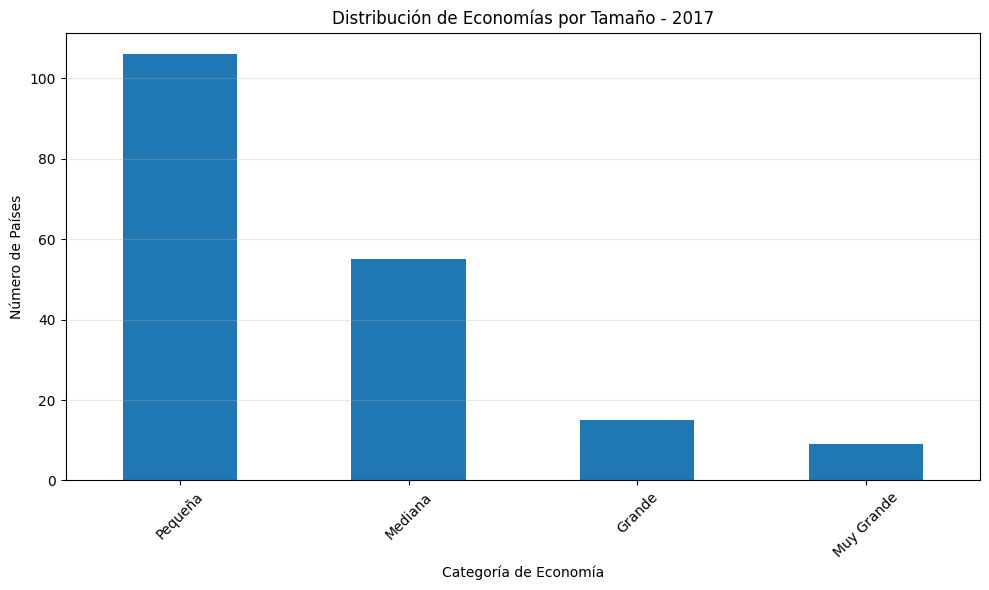


=== TOP 10 ECONOMÍAS MÁS GRANDES EN 2017 ===
              Entity  gdp_billions categoría_economía
8494   United States  17304.984279         Muy Grande
1783           China  10161.012759         Muy Grande
4261           Japan   6156.328721         Muy Grande
3130         Germany   3865.759081         Muy Grande
2919          France   2857.089402         Muy Grande
8436  United Kingdom   2806.903097         Muy Grande
3789           India   2629.542212         Muy Grande
1174          Brazil   2278.936373         Muy Grande
4151           Italy   2111.901941         Muy Grande
1513          Canada   1883.707912             Grande


In [ ]:
# Analizamos la distribución en 2017
df_2017 = df[df['Year'] == 2017].copy()

if len(df_2017) > 0:
    print("=== DISTRIBUCIÓN POR TAMAÑO DE ECONOMÍA EN 2017 ===")
    distribucion = df_2017['categoría_economía'].value_counts()
    print(distribucion)

    # Visualización básica
    plt.figure(figsize=(10, 6))
    distribucion.plot(kind='bar')
    plt.title('Distribución de Economías por Tamaño - 2017')
    plt.xlabel('Categoría de Economía')
    plt.ylabel('Número de Países')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\n=== TOP 10 ECONOMÍAS MÁS GRANDES EN 2017 ===")
    top_economies = df_2017.nlargest(10, 'gdp_billions')[['Entity', 'gdp_billions', 'categoría_economía']]
    print(top_economies)
else:
    print("No hay datos disponibles para 2017")